# Análisis de Correlación trabajo 3

Importación de Bibliotecas

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as ss

from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from IPython.display import Image, display
from itertools import combinations



# 1.Contextualización del estudio

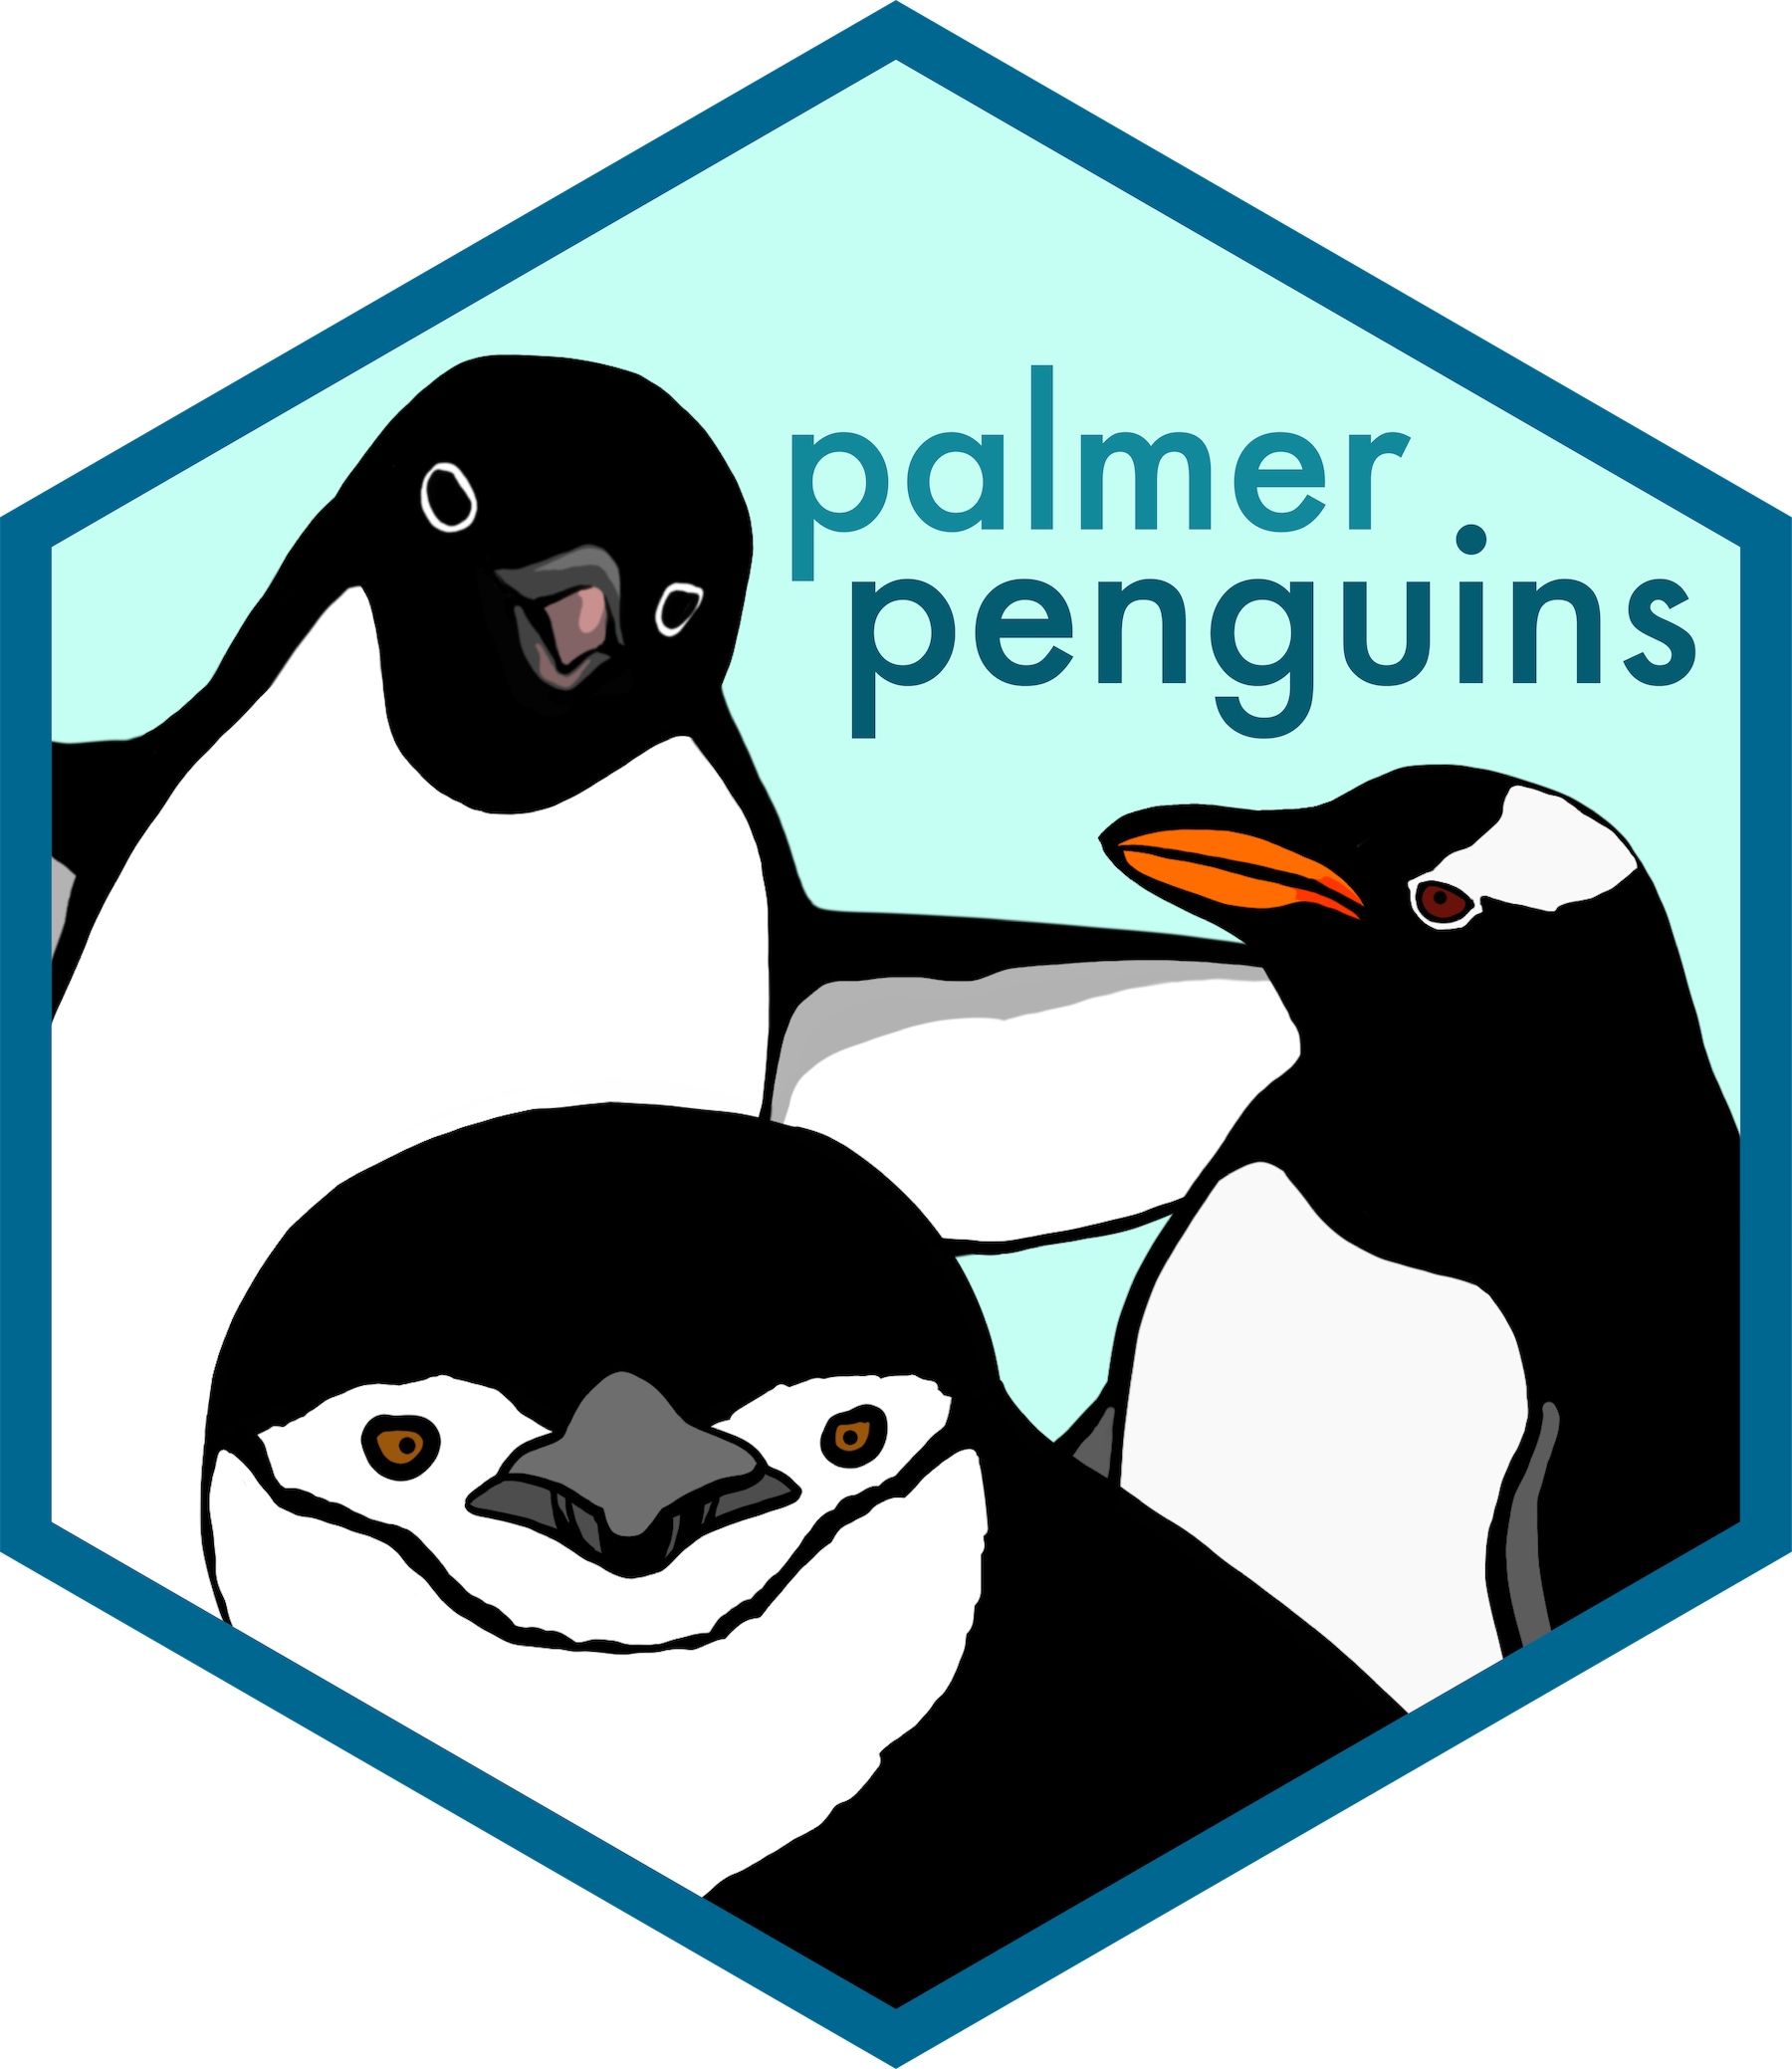

In [170]:

display(Image(filename="palmerpenguins.png", width=400))

El conjunto de datos Palmer Penguins contiene información de 342 pingüinos antárticos pertenecientes al género Pygoscelis, recolectados en las islas del archipiélago Palmer, en la Antártida, como parte del programa Palmer Station Long-Term Ecological Research (PAL-LTER).

El propósito original de la recopilación de estos datos fue estudiar las características morfológicas de las distintas especies de pingüinos y su relación con la variabilidad ambiental, con especial interés en comprender aspectos asociados a su comportamiento de alimentación y adaptación al ecosistema antártico.

En el presente trabajo, la población de estudio está conformada por la totalidad de los 342 individuos registrados en la base de datos, distribuidos en tres especies:

#### Objetivo del Estudio
Analizar las diferencias morfológicas (físicas) y de distribución geográfica entre tres especies de pingüinos antárticos del género *Pygoscelis*.

* **Periodo de recolección:** 2007 – 2009
* **Ubicación:** Archipiélago Palmer, Antártida
* **Muestra:** 344 observaciones (342 registros completos)

Especies Estudiadas y Distribución Geográfica

| Especie | Nombre Científico | Islas donde habita en el dataset | Muestra |
| :--- | :--- | :--- | :---: |
| **Adelia (Adelie)** | *Pygoscelis adeliae* | Biscoe, Dream, Torgersen | 151 |
| **Gentoo (Papúa)** | *Pygoscelis papua* | Biscoe | 123 |
| **Barbijo (Chinstrap)** | *Pygoscelis antarcticus* | Dream | 68 |

> **Nota Biológica:** La especie *Adelie* se encuentra presente en todas las islas estudiadas, mientras que *Gentoo* y *Chinstrap* habitan zonas específicas en esta muestra.

---

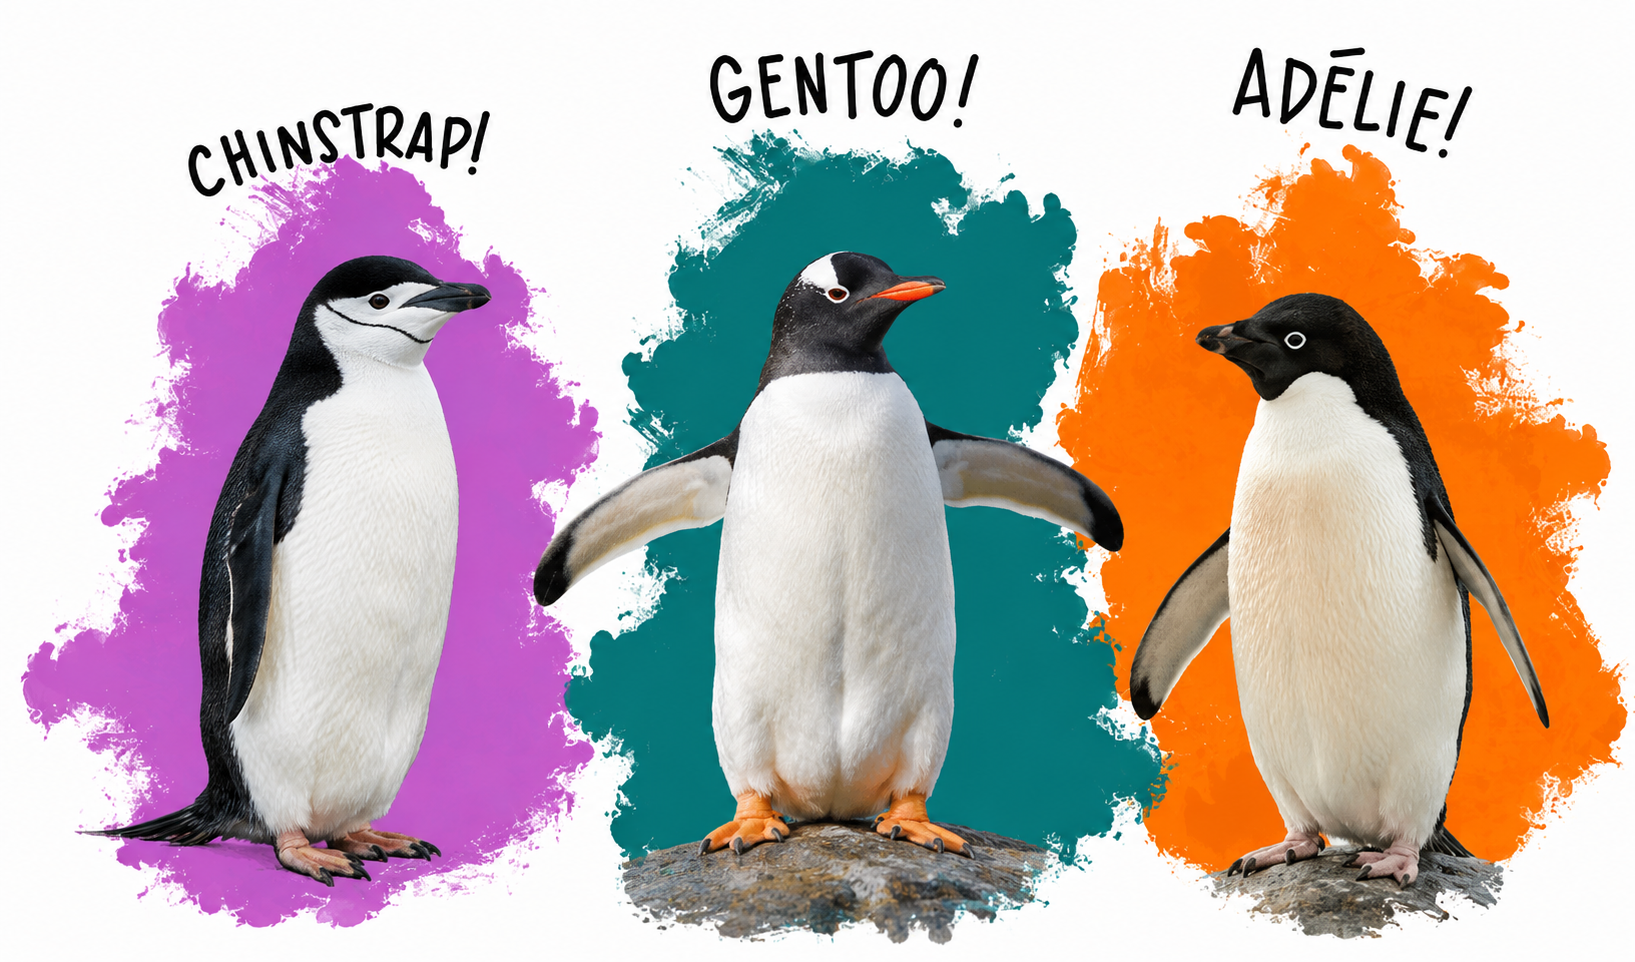

In [145]:

display(Image(filename="pin.png", width=1000))

Variables principales

| Variable | Tipo de Dato | Descripción | Unidad |
| :--- | :--- | :--- | :--- |
| `species` | Categórica | Especie del pingüino (*Adelie*, *Gentoo*, *Chinstrap*) | - |
| `island` | Categórica | Isla de recolección (*Biscoe*, *Dream*, *Torgersen*) | - |
| `bill_length_mm` | Numérica (Continua) | Longitud del culmen/pico | milímetros (mm) |
| `bill_depth_mm` | Numérica (Continua) | Profundidad/grosor del culmen/pico | milímetros (mm) |
| `flipper_length_mm` | Numérica (Continua) | Longitud de la aleta | milímetros (mm) |
| `body_mass_g` | Numérica (Continua) | Masa corporal total del ave | gramos (g) |
| `sex` | Categórica | Sexo del espécimen (*male*, *female*) | - |
| `year` | Numérica (Discreta) | Año en que se tomó la muestra (2007, 2008, 2009) | Año |

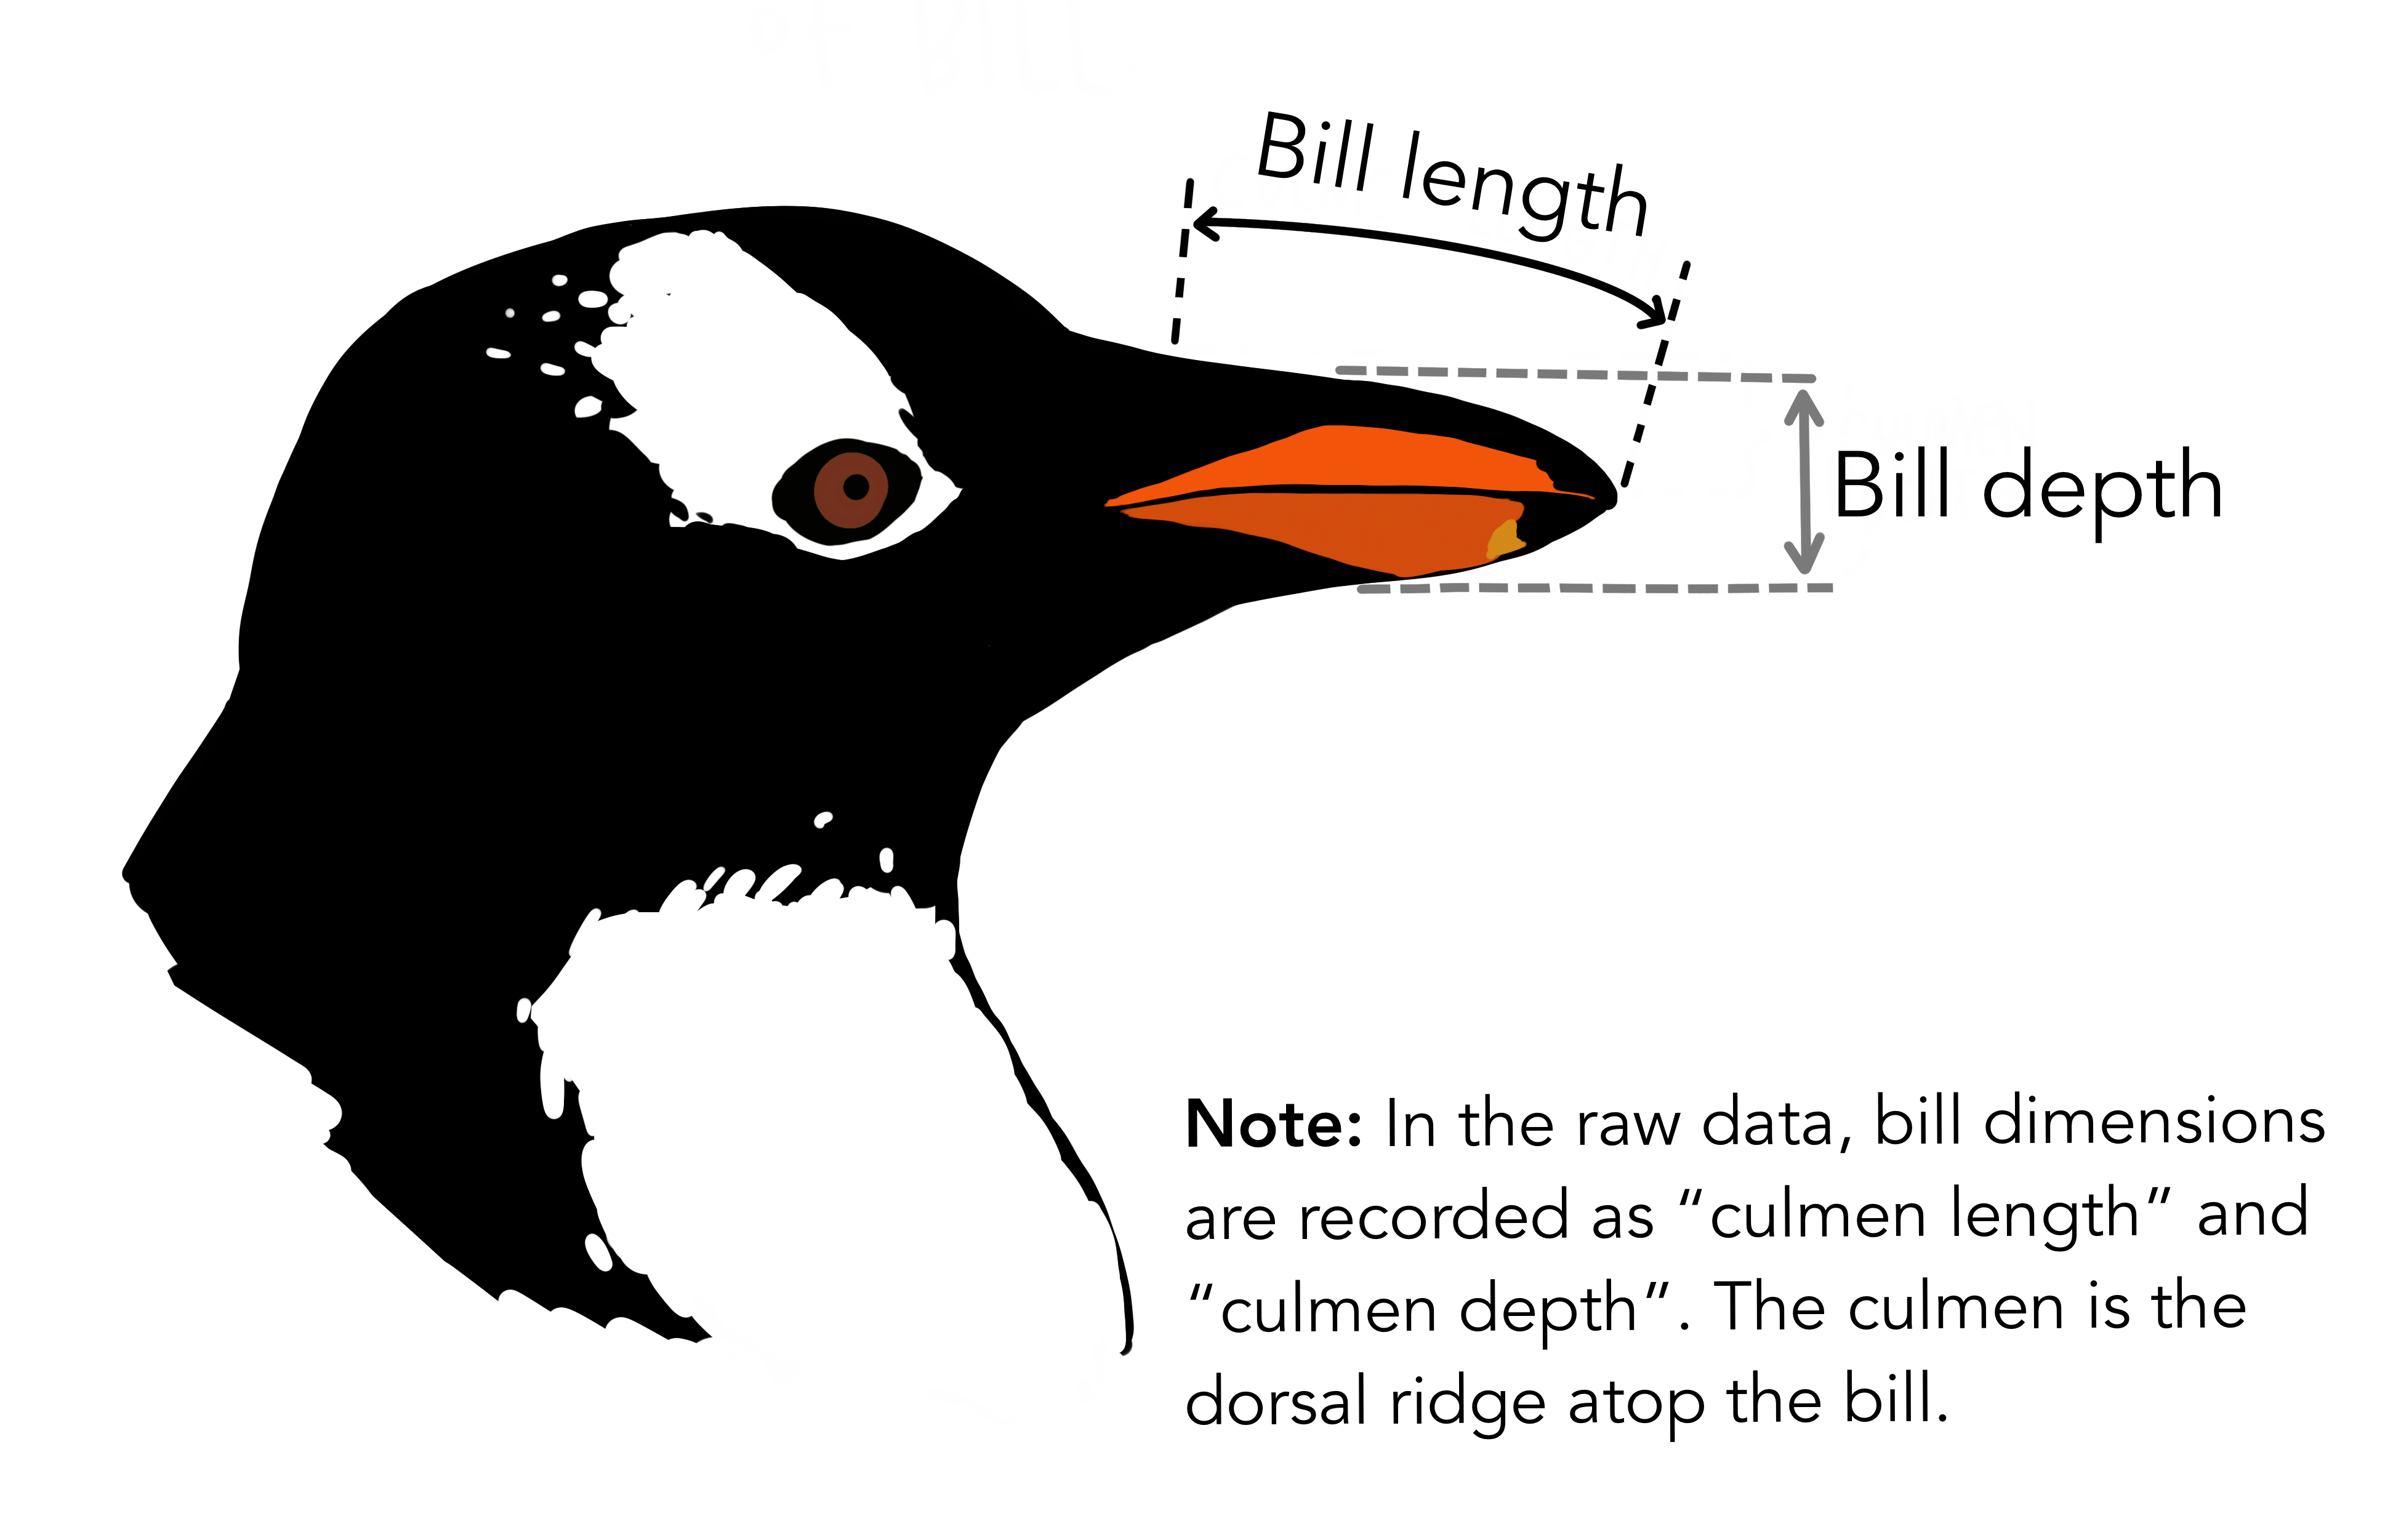

In [14]:
display(Image(filename="culmen_depth.png", width=600))

Financiamiento. La recopilación de los datos fue realizada en el marco del programa Palmer Station Long-Term Ecological Research (PAL-LTER), financiado por la National Science Foundation – Office of Polar Programs (NSF-OPP).

cargar del dataset

In [3]:
data = pd.read_csv('PalmerPenguins.csv',sep=";")

In [4]:
data.head(5)

,species,isla,longitud_pico_mm,grosor_pico_mm,longitud_aleta_mm,masa_corporal_g,sexo,year
0,Adelie,Torgersen,39.1,18.7,181,3750,male,2007
1,Adelie,Torgersen,39.5,17.4,186,3800,female,2007
2,Adelie,Torgersen,40.3,18.0,195,3250,female,2007
3,Adelie,Torgersen,36.7,19.3,193,3450,female,2007
4,Adelie,Torgersen,39.3,20.6,190,3650,male,2007


In [27]:

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            342 non-null    object 
 1   isla               342 non-null    object 
 2   longitud_pico_mm   342 non-null    float64
 3   grosor_pico_mm     342 non-null    float64
 4   longitud_aleta_mm  342 non-null    int64  
 5   masa_corporal_g    342 non-null    int64  
 6   sexo               333 non-null    object 
 7   year               342 non-null    int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 21.5+ KB


# 2. Estadistica descriptiva

## 2.1. Variables categóricas

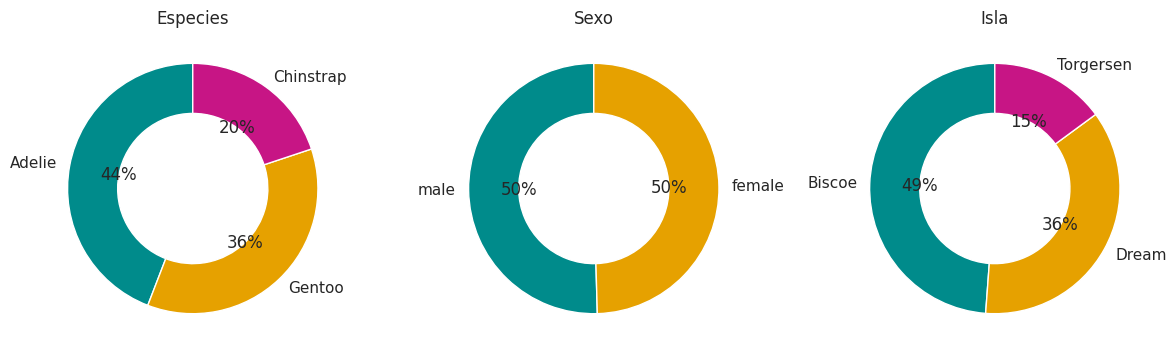

In [154]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
# Paleta de colores: Turquesa, Amarillo/Dorado, Magenta
colores = ['#008B8B', '#E6A100', '#C71585']

for ax, col, tit in zip(axes, ['species', 'sexo', 'isla'], ['Especies', 'Sexo', 'Isla']):
    data[col].value_counts().plot.pie(
        ax=ax, autopct='%1.0f%%', startangle=90, colors=colores,
        ylabel='', title=tit, wedgeprops=dict(width=0.4) # Crea el efecto de dona
    )

plt.tight_layout()
plt.show()

## 2.2.Variables cuantitativas

In [155]:
data.describe()

,longitud_pico_mm,grosor_pico_mm,longitud_aleta_mm,masa_corporal_g,year
count,342.000000,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029240
std,5.459584,1.974793,14.061714,801.954536,0.817168
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


### 2.2.1 diagrama de cajas

/tmp/ipykernel_1012/3394493522.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_1012/3394493522.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_1012/3394493522.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_1012/3394493522.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




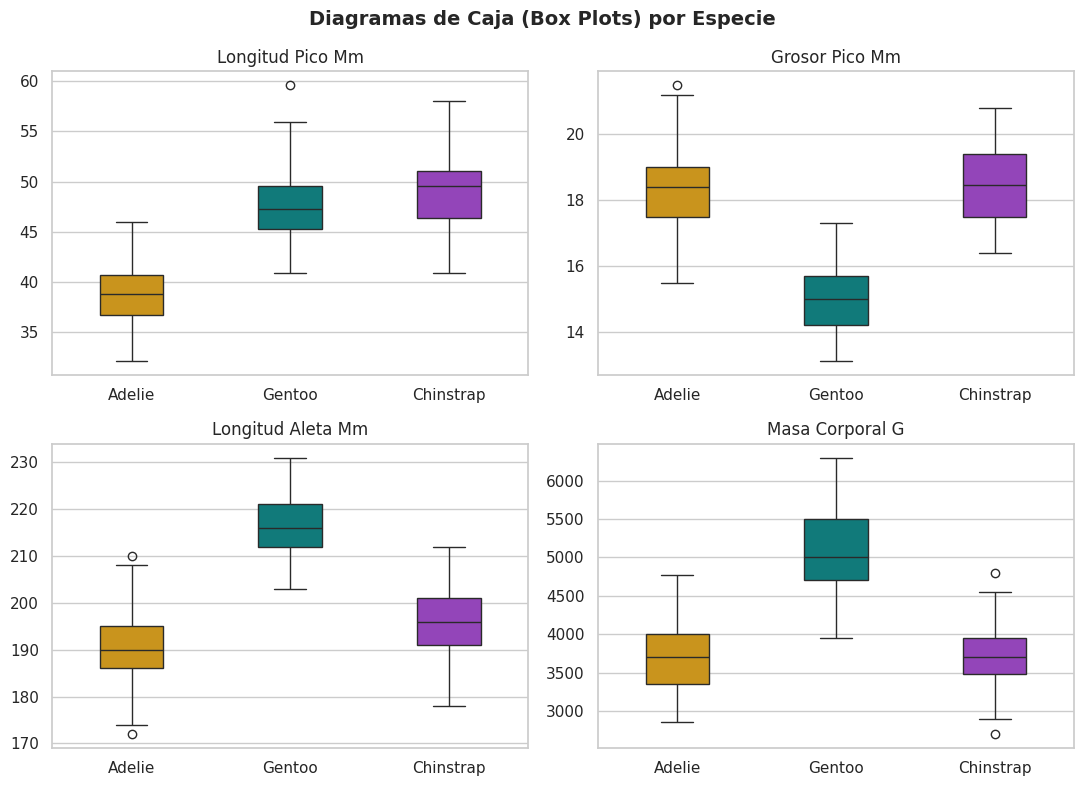

In [147]:
# Lista con los nombres exactos de tus variables ya renombradas
variables = ['longitud_pico_mm', 'grosor_pico_mm', 'longitud_aleta_mm', 'masa_corporal_g']

# Variables y paleta de colores
vars_num = ['longitud_pico_mm', 'grosor_pico_mm', 'longitud_aleta_mm', 'masa_corporal_g']
paleta = {'Adelie': '#E69F00', 'Chinstrap': '#9932CC', 'Gentoo': '#008B8B'}

# Configurar lienzo 2x2
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.suptitle('Diagramas de Caja (Box Plots) por Especie', fontsize=14, fontweight='bold')

# Generar gráficos en bucle
for ax, var in zip(axes.flatten(), vars_num):
    sns.boxplot(data=data, x='species', y=var, palette=paleta, ax=ax, width=0.4)
    ax.set(title=var.replace('_', ' ').title(), xlabel='', ylabel='')

plt.tight_layout()
plt.show()

### 2.2.2 grafica de distribución

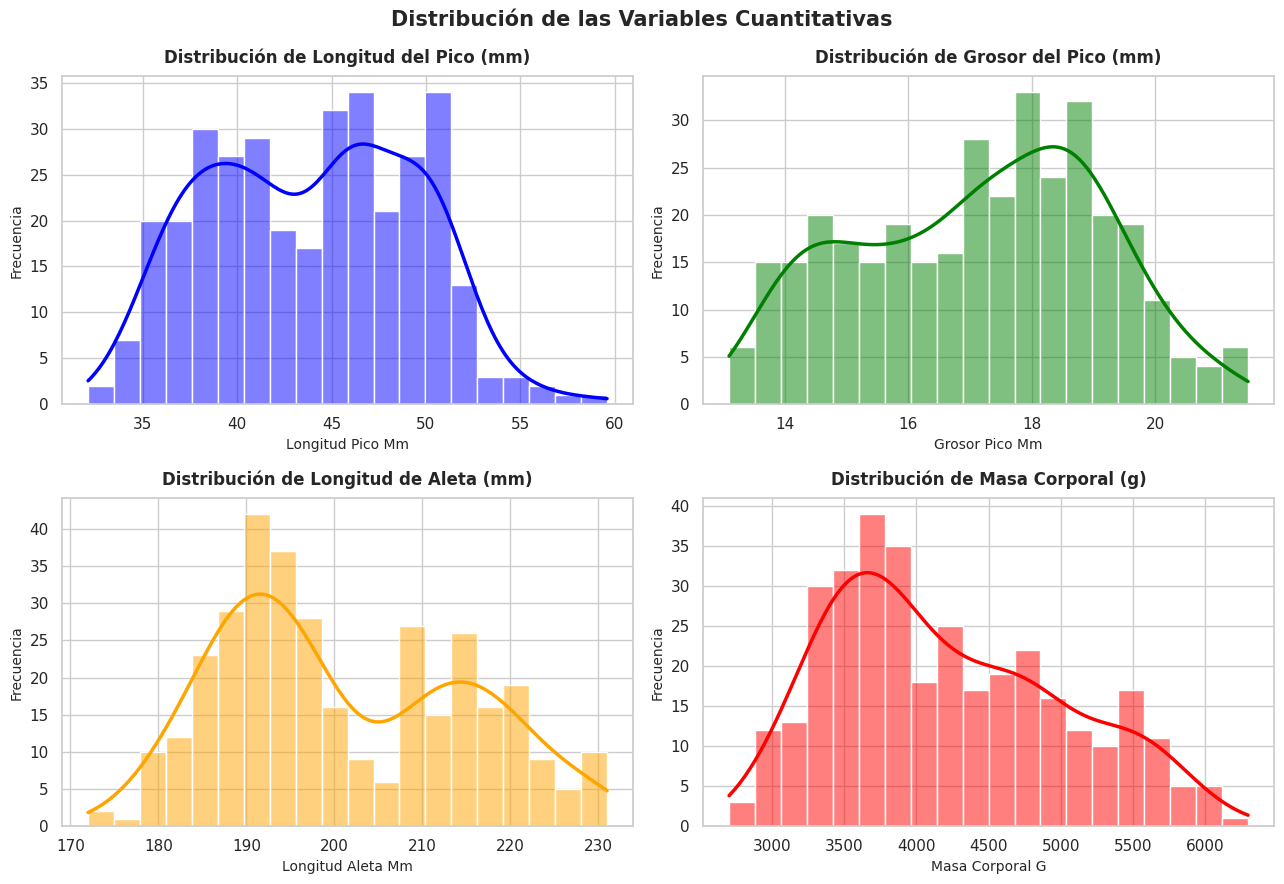

In [171]:
# Configuración del lienzo gráfico
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Distribución de las Variables Cuantitativas', fontsize=15, fontweight='bold', y=0.98)

# Configuración de títulos y colores por variable
configuracion = [
    ('longitud_pico_mm', 'Distribución de Longitud del Pico (mm)', 'blue'),
    ('grosor_pico_mm', 'Distribución de Grosor del Pico (mm)', 'green'),
    ('longitud_aleta_mm', 'Distribución de Longitud de Aleta (mm)', 'orange'),
    ('masa_corporal_g', 'Distribución de Masa Corporal (g)', 'red')
]

# Generar la cuadrícula de histogramas con curva KDE
for ax, (var, titulo, color) in zip(axes.flatten(), configuracion):
    sns.histplot(
        data=data,
        x=var,
        kde=True,
        color=color,
        ax=ax,
        bins=20,
        line_kws={'linewidth': 2.5}
    )
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel(var.replace('_', ' ').title(), fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)

plt.tight_layout()
plt.show()

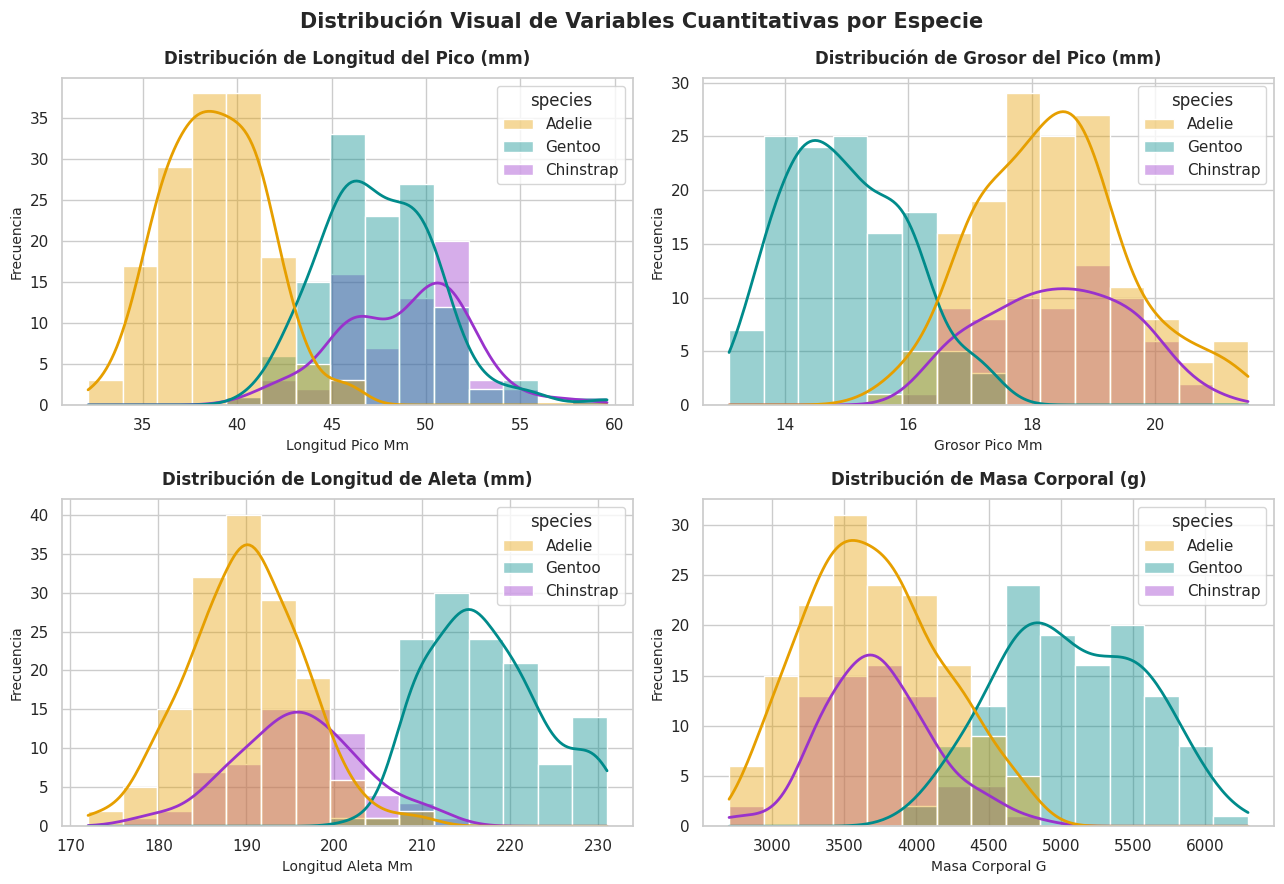

In [173]:
# Configuración del lienzo gráfico
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Distribución Visual de Variables Cuantitativas por Especie', fontsize=15, fontweight='bold', y=0.98)

# Variables y títulos
configuracion = [
    ('longitud_pico_mm', 'Distribución de Longitud del Pico (mm)'),
    ('grosor_pico_mm', 'Distribución de Grosor del Pico (mm)'),
    ('longitud_aleta_mm', 'Distribución de Longitud de Aleta (mm)'),
    ('masa_corporal_g', 'Distribución de Masa Corporal (g)')
]

# Paleta de colores consistente
paleta = {'Adelie': '#E69F00', 'Chinstrap': '#9932CC', 'Gentoo': '#008B8B'}

# Generar la cuadrícula desagregada por especie
for ax, (var, titulo) in zip(axes.flatten(), configuracion):
    sns.histplot(
        data=data,
        x=var,
        hue='species',
        palette=paleta,
        kde=True,
        ax=ax,
        bins=15,
        alpha=0.4,
        line_kws={'linewidth': 2}
    )
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel(var.replace('_', ' ').title(), fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)

plt.tight_layout()
plt.show()

Los histogramas con curvas de densidad revelan patrones de segregación morfológica clave entre especies que explican la falta de normalidad global en el dataset. La especie Gentoo se destaca claramente como la más grande y distinta, ubicándose en el extremo superior en longitud de aleta (superando los $210\text{ mm}$) y masa corporal (concentrada entre $4,500\text{ g}$ y $6,000\text{ g}$), pero exhibiendo el grosor de pico más delgado ($13\text{ mm} - 16\text{ mm}$). Por su parte, Adelie y Chinstrap presentan solapamientos considerables en masa corporal y aletas en la zona inferior del espectro, pero se diferencian de manera drástica en la longitud del pico, donde Adelie agrupa sus valores en rangos menores ($33\text{ mm} - 42\text{ mm}$) mientras Chinstrap alcanza longitudes superiores similares a Gentoo ($45\text{ mm} - 55\text{ mm}$). Visualmente, estas superposiciones parciales y desplazamientos entre grupos confirman la bimodalidad y multimodaldad de la población conjunta, respaldando de nuevo la decisión de analizar el dataset de forma segmentada por especie.

### 2.2.3 Prueba de normalidad

In [ ]:
#Prueba de normalidad (Shapiro)
#Ho: La variable se aproxima a una distribución normal
#Ha: La variable NO se aproxima a una distribución normal

#Si p-value < 5%, se rechaza la hipótesis nula (Ho),
#al 95% de confianza, la variable NO se aproxima a una distribución normal.

#Si p-value > 5%, no se rechaza la hipótesis nula (Ho),
#al 95% de confianza, la variable se aproxima a una distribución normal.

In [174]:
variables = ['longitud_pico_mm', 'grosor_pico_mm', 'longitud_aleta_mm', 'masa_corporal_g']
resultados = []

# 1. Evaluar Global y por Especie en un solo ciclo
for grupo, sub_df in [('GLOBAL (Todas)', data)] + list(data.groupby('species')):
    for var in variables:
        stat, p_val = stats.shapiro(sub_df[var])

        interpretacion = (
            "Al 95% de confianza, los datos se aproximan a una distribución normal"
            if p_val > 0.05 else
            "Al 95% de confianza, los datos NO se aproximan a una distribución normal"
        )

        resultados.append({
            'Grupo': grupo,
            'Variable': var,
            'Estadístico W': round(stat, 4),
            'p-valor': round(p_val, 5),
            'Resultado': interpretacion
        })

# 2. Mostrar la tabla consolidada
df_normalidad_completa = pd.DataFrame(resultados)
display(df_normalidad_completa)

,Grupo,Variable,Estadístico W,p-valor,Resultado
0,GLOBAL (Todas),longitud_pico_mm,0.9749,0.00001,"Al 95% de confianza, los datos NO se aproximan..."
1,GLOBAL (Todas),grosor_pico_mm,0.9726,0.00000,"Al 95% de confianza, los datos NO se aproximan..."
2,GLOBAL (Todas),longitud_aleta_mm,0.9515,0.00000,"Al 95% de confianza, los datos NO se aproximan..."
3,GLOBAL (Todas),masa_corporal_g,0.9592,0.00000,"Al 95% de confianza, los datos NO se aproximan..."
4,Adelie,longitud_pico_mm,0.9934,0.71660,"Al 95% de confianza, los datos se aproximan a ..."
5,Adelie,grosor_pico_mm,0.9847,0.09249,"Al 95% de confianza, los datos se aproximan a ..."
6,Adelie,longitud_aleta_mm,0.9934,0.72005,"Al 95% de confianza, los datos se aproximan a ..."
7,Adelie,masa_corporal_g,0.9807,0.03240,"Al 95% de confianza, los datos NO se aproximan..."
8,Chinstrap,longitud_pico_mm,0.9752,0.19409,"Al 95% de confianza, los datos se aproximan a ..."
9,Chinstrap,grosor_pico_mm,0.9727,0.14178,"Al 95% de confianza, los datos se aproximan a ..."


Los resultados de la prueba de Shapiro-Wilk justifican metodológicamente desagregar el análisis por especie y utilizar estadística no paramétrica. A nivel global, la mezcla de poblaciones oculta la estructura real de los datos y hace que todas las variables rechacen la hipótesis de normalidad ($p < 0.05$). Sin embargo, al segmentar por subgrupos, la normalidad emerge con claridad en la especie Chinstrap para todas sus métricas y en Adelie para la mayoría de sus variables morfológicas. Este comportamiento confirma que la falta de normalidad generalizada responde a un sesgo por mezcla de especies (bimodalidad) y no a un ruido atípico en las mediciones, validando el uso del coeficiente de Spearman como la métrica más robusta y confiable para evaluar las relaciones lineales y no lineales del dataset.

# 3. MATRIZ DE CORRELACIÓN

In [ ]:
data.loc[:,['masa_corporal_g','longitud_aleta_mm','grosor_pico_mm','longitud_pico_mm']].corr(method = "spearman")

,masa_corporal_g,longitud_aleta_mm,grosor_pico_mm,longitud_pico_mm
masa_corporal_g,1.000000,0.839974,-0.432372,0.583800
longitud_aleta_mm,0.839974,1.000000,-0.523267,0.672772
grosor_pico_mm,-0.432372,-0.523267,1.000000,-0.221749
longitud_pico_mm,0.583800,0.672772,-0.221749,1.000000


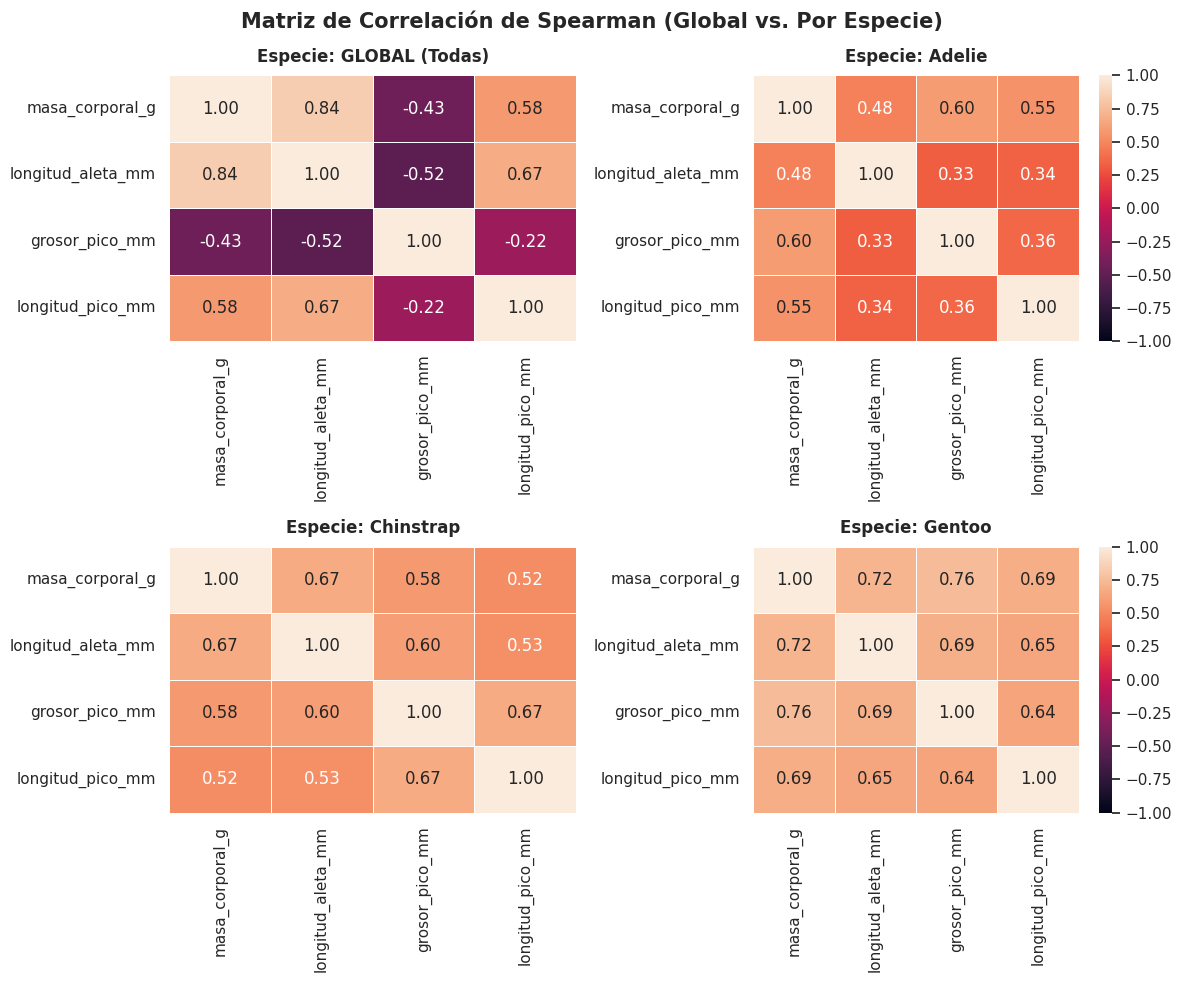

In [133]:
# Lista de variables a evaluar
vars_num = ['masa_corporal_g', 'longitud_aleta_mm', 'grosor_pico_mm', 'longitud_pico_mm']

# Configuración del lienzo 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Matriz de Correlación de Spearman (Global vs. Por Especie)', fontsize=15, fontweight='bold', y=0.98)

# Definir los grupos a graficar
grupos = [('GLOBAL (Todas)', data)] + list(data.groupby('species'))

# Generar un heatmap para cada subgrupo
for ax, (titulo, sub_df) in zip(axes.flatten(), grupos):
    matriz_corr = sub_df[vars_num].corr(method="spearman")

    sns.heatmap(
        matriz_corr,
        annot=True,
        fmt=".2f",
        vmin=-1, vmax=1,
        linewidths=0.5,
        cbar=(ax == axes[0, 1] or ax == axes[1, 1]), # Mantiene la barra solo en el lado derecho
        ax=ax
    )
    ax.set_title(f"Especie: {titulo}", fontsize=12, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

 En el gráfico GLOBAL, el grosor del pico muestra una relación negativa moderada con la masa corporal ($-0.43$) y la longitud de la aleta ($-0.52$), lo que sugeriría erróneamente una tendencia inversamente proporcional. Sin embargo, al segmentar por especie (Adelie, Chinstrap y Gentoo), todas las correlaciones se vuelven estrictamente positivas (alcanzando hasta $0.76$ entre masa y grosor en Gentoo), demostrando que las asociaciones negativas globales son un artefacto estadístico causado por diferencias morfológicas entre grupos (Gentoo es considerablemente más grande pero tiene picos proporcionalmente más delgados). Asimismo, se consolida la masa corporal como el principal predictor del tamaño físico general, presentando relaciones positivas consistentes y de moderadas a fuertes con las tres variables restantes en cada subpoblación.

# 4.Prueba de Correlación entre la masa total y las demas variables

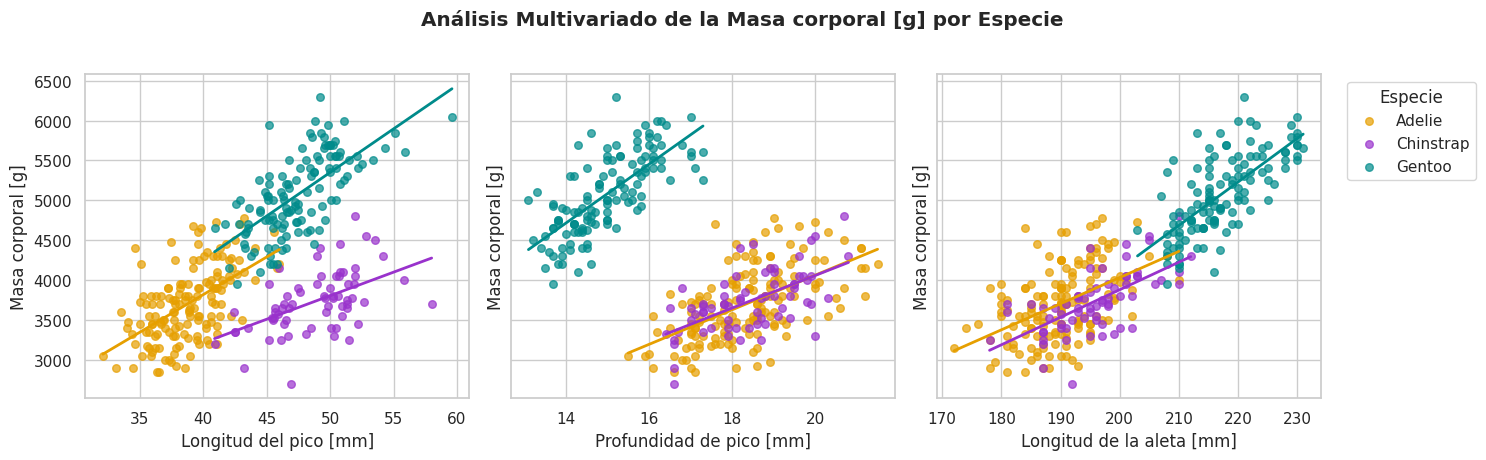

In [159]:

# Configuración inicial
hue = 'species'
paleta = {'Adelie': '#E69F00', 'Chinstrap': '#9932CC', 'Gentoo': '#008B8B'}
var_y, y_label = 'masa_corporal_g', 'Masa corporal [g]'
variables_x = [
    ('longitud_pico_mm', 'Longitud del pico [mm]'),
    ('grosor_pico_mm', 'Profundidad de pico [mm]'),
    ('longitud_aleta_mm', 'Longitud de la aleta [mm]')
]

# Crear lienzo 1x3
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4.5), sharey=True)

# Generar gráficos con masa_corporal_g en el eje Y (Variable independiente)
for i, (var_x, x_label) in enumerate(variables_x):
    for especie, color in paleta.items():
        sub_df = data[data[hue] == especie]
        sns.regplot(
            data=sub_df, x=var_x, y=var_y, ax=axes[i], color=color, label=especie,
            ci=None, scatter_kws={'s': 30, 'alpha': 0.7}, line_kws={'linewidth': 2}
        )
    axes[i].set(xlabel=x_label, ylabel=y_label)
    if i == 2:
        axes[i].legend(title='Especie', bbox_to_anchor=(1.05, 1), loc='upper left')

fig.suptitle(f'Análisis Multivariado de la {y_label} por Especie', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

El análisis multivariado confirma relaciones lineales positivas entre la masa corporal y las tres dimensiones físicas evaluadas, evidenciando patrones de crecimiento propios para cada especie. La longitud de la aleta demuestra ser el correlato alométrico más estable y consistente en todo el dataset, mostrando pendientes alineadas y una clara continuidad entre especies donde mayores dimensiones de aleta corresponden a un peso sustancialmente mayor (especialmente en Gentoo). Por otro lado, la profundidad del pico ratifica el comportamiento de la Paradoja de Simpson: aunque dentro de Adelie, Chinstrap y Gentoo existe una pendiente positiva clara a mayor grosor de pico, mayor masa corporal, el clúster de Gentoo se desplaza drásticamente hacia el extremo izquierdo (picos más delgados pero cuerpos más pesados). En conjunto, los gráficos de dispersión con regresión validan que la masa corporal es el principal factor de escala física y que Gentoo posee una estructura morfológica diferenciada de Adelie y Chinstrap.

In [ ]:
#Prueba de Correlación
#Ho: no existe correlación entre las variables
#Ha: existe correlación entre las variables

#Si p-value < 5%, se rechaza la hipótesis nula (Ho),
#al 95% de confianza, existe correlación entre las variables.

#Si p-value > 5%, no se rechaza la hipótesis nula (Ho),
#al 95% de confianza, no existe correlación entre las variables.

In [166]:

var_base = 'masa_corporal_g'
variables_comparar = [
    ('longitud_pico_mm', 'Longitud Pico'),
    ('grosor_pico_mm', 'Grosor Pico'),
    ('longitud_aleta_mm', 'Longitud Aleta')
]

filas = []
for var, var_label in variables_comparar:
    for especie, sub_df in [('GLOBAL (Todas)', data)] + list(data.groupby('species')):
        coef, p_val = ss.spearmanr(sub_df[var_base], sub_df[var], nan_policy='omit')

        filas.append({
            'Variable vs Masa Corporal': var_label,
            'Grupo': especie,
            'Spearman (rho)': round(coef, 4),
            'p-valor': round(p_val, 4),
            'Significativo (95%)': 'Al 95% de confianza, existe relación significativa'
            if p_val < 0.05 else 'Al 95% de confianza, no existe relación significativa'
        })

# 1. Crear el DataFrame
df_spearman = pd.DataFrame(filas)

# 2. Agrupar indexando primero por la Variable
tabla_por_variable = df_spearman.set_index(['Variable vs Masa Corporal', 'Grupo'])
display(tabla_por_variable)


Spearman (rho)  p-valor  \
Variable vs Masa Corporal Grupo                                     
Longitud Pico             GLOBAL (Todas)          0.5838      0.0   
                          Adelie                  0.5494      0.0   
                          Chinstrap               0.5246      0.0   
                          Gentoo                  0.6851      0.0   
Grosor Pico               GLOBAL (Todas)         -0.4324      0.0   
                          Adelie                  0.5958      0.0   
                          Chinstrap               0.5791      0.0   
                          Gentoo                  0.7555      0.0   
Longitud Aleta            GLOBAL (Todas)          0.8400      0.0   
                          Adelie                  0.4755      0.0   
                          Chinstrap               0.6705      0.0   
                          Gentoo                  0.7167      0.0   

                                                                        Significativo (95%)  
Variable vs Masa Corporal Grupo                                                              
Longitud Pico             GLOBAL (Todas)  Al 95% de confianza, existe relación significa...  
                          Adelie          Al 95% de confianza, existe relación significa...  
                          Chinstrap       Al 95% de confianza, existe relación significa...  
                          Gentoo          Al 95% de confianza, existe relación significa...  
Grosor Pico               GLOBAL (Todas)  Al 95% de confianza, existe relación significa...  
                          Adelie          Al 95% de confianza, existe relación significa...  
                          Chinstrap       Al 95% de confianza, existe relación significa...  
                          Gentoo          Al 95% de confianza, existe relación significa...  
Longitud Aleta            GLOBAL (Todas)  Al 95% de confianza, existe relación significa...  
                          Adelie          Al 95% de confianza, existe relación significa...  
                          Chinstrap       Al 95% de confianza, existe relación significa...  
                          Gentoo          Al 95% de confianza, existe relación significa...

Como p-value < 5%, se rechaza la hipótesis nula (Ho),
al 95% de confianza, existe correlación entre las variables:
masa_corporal_g vs Longitud Pico | Grosor pico | Longitud de aleta.

Al 95% de confianza, se cumple la linealidad entre la variables dependiente (target) vs las variables
independientes.

# 5. Prueba de Correlación entre X1, X2, X3

In [117]:


# Variables cuantitativas
vars_num = ['longitud_aleta_mm', 'longitud_pico_mm']
pares = list(combinations(vars_num, 2))

#  Correlación Global y por Especie
filas = []
for especie, sub_df in [('GLOBAL (Todas)', data)] + list(data.groupby('species')):
    for var1, var2 in pares:
        coef, p_val = ss.spearmanr(sub_df[var1], sub_df[var2])
        filas.append({
            'Grupo': especie,
            'Spearman (rho)': round(coef, 4),
            'p-valor': round(p_val, 4),
            'Significativo (95%)': 'Al 95% de confianza, existe relación significativa' if p_val < 0.05
            else 'Al 95% de confianza, no existe relación significativa'
        })

# tabla
tabla_spearman = pd.DataFrame(filas)
display(tabla_spearman)

,Grupo,Spearman (rho),p-valor,Significativo (95%)
0,GLOBAL (Todas),0.6728,0.0,"Al 95% de confianza, existe relación significa..."
1,Adelie,0.3392,0.0,"Al 95% de confianza, existe relación significa..."
2,Chinstrap,0.5330,0.0,"Al 95% de confianza, existe relación significa..."
3,Gentoo,0.6471,0.0,"Al 95% de confianza, existe relación significa..."


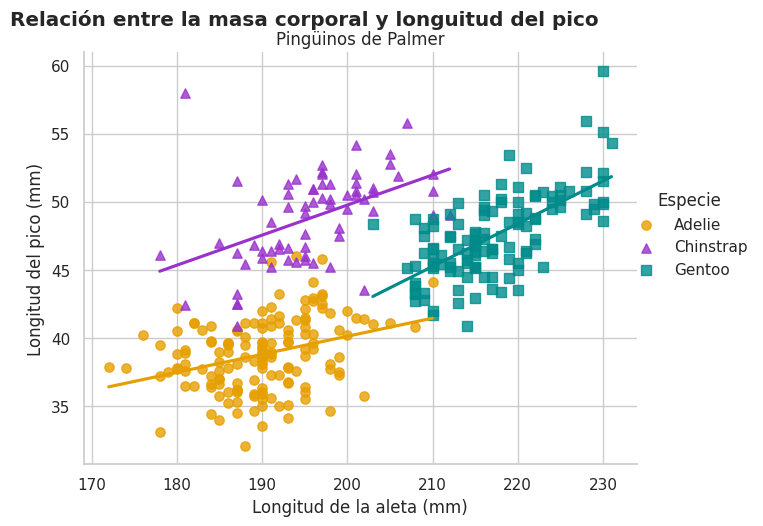

In [79]:



g = sns.lmplot(
    data=data, x='longitud_aleta_mm', y='longitud_pico_mm', hue='species',
    hue_order=['Adelie', 'Chinstrap', 'Gentoo'],
    palette={'Adelie': '#E69F00', 'Chinstrap': '#9932CC', 'Gentoo': '#008B8B'},
    markers=['o', '^', 's'], scatter_kws={'s': 45}, ci=None, height=5, aspect=1.3
)

g.fig.suptitle('Relación entre la masa corporal y longuitud del pico', x=0.02, y=1.05, ha='left', fontweight='bold')
g.ax.set(title='Pingüinos de Palmer', xlabel='Longitud de la aleta (mm)', ylabel='Longitud del pico (mm)')
g._legend.set_title('Especie')
sns.move_legend(g, "center left", bbox_to_anchor=(0.8, 0.6))


plt.show()

El gráfico de dispersión revela una marcada segregación ecomorfológica entre las tres especies de pingüinos al analizar la relación entre la longitud de la aleta y la longitud del pico. Las tres poblaciones muestran pendientes de regresión positivas, confirmando que dentro de cada grupo un mayor tamaño de aleta se asocia de forma consistente con un pico más largo. No obstante, sus distribuciones en el espacio bidimensional son claramente distintas: Adelie ocupa la zona inferior con aletas y picos proporcionalmente más cortos ($170\text{ mm} - 200\text{ mm}$ de aleta; $32\text{ mm} - 45\text{ mm}$ de pico); Chinstrap comparte el mismo rango de longitud de aleta que Adelie pero se desplaza hacia arriba con picos significativamente más largos ($45\text{ mm} - 58\text{ mm}$); finalmente, Gentoo se aísla por completo en el extremo derecho, caracterizándose por presentar las aletas más largas del estudio ($205\text{ mm} - 230\text{ mm}$) combinadas con picos también extensos ($42\text{ mm} - 60\text{ mm}$). Esta clara agrupación por clusters confirma que la especie es el factor primario de diferenciación fenotípica en el conjunto de datos.

In [119]:



# Variables cuantitativas
vars_num = ['grosor_pico_mm', 'longitud_pico_mm']
pares = list(combinations(vars_num, 2))

#  Correlación Global y por Especie
filas = []
for especie, sub_df in [('GLOBAL (Todas)', data)] + list(data.groupby('species')):
    for var1, var2 in pares:
        coef, p_val = ss.spearmanr(sub_df[var1], sub_df[var2])
        filas.append({
            'Grupo': especie,
            'Spearman (rho)': round(coef, 4),
            'p-valor': round(p_val, 4),
            'Significativo (95%)': 'Al 95% de confianza, existe relación significativa' if p_val < 0.05
            else 'Al 95% de confianza, no existe relación significativa'
        })

# tabla
tabla_spearman = pd.DataFrame(filas)
display(tabla_spearman)

,Grupo,Spearman (rho),p-valor,Significativo (95%)
0,GLOBAL (Todas),-0.2217,0.0,"Al 95% de confianza, existe relación significa..."
1,Adelie,0.3627,0.0,"Al 95% de confianza, existe relación significa..."
2,Chinstrap,0.6715,0.0,"Al 95% de confianza, existe relación significa..."
3,Gentoo,0.6354,0.0,"Al 95% de confianza, existe relación significa..."


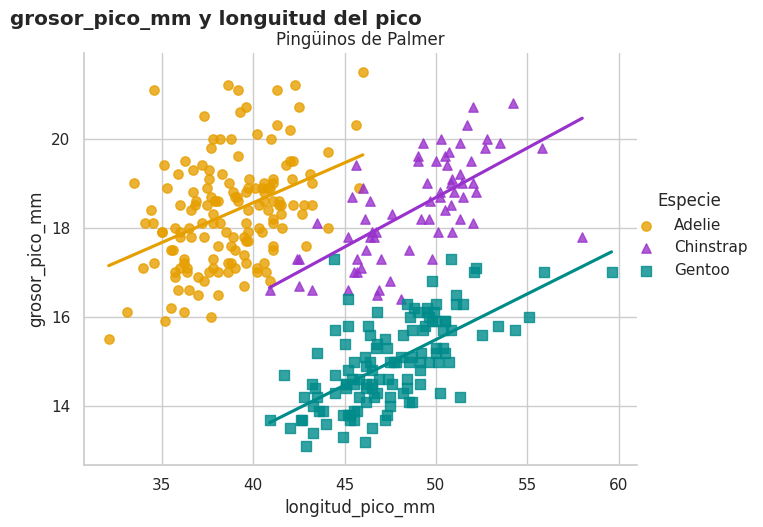

In [168]:


g = sns.lmplot(
    data=data, x='longitud_pico_mm', y='grosor_pico_mm', hue='species',
    hue_order=['Adelie', 'Chinstrap', 'Gentoo'],
    palette={'Adelie': '#E69F00', 'Chinstrap': '#9932CC', 'Gentoo': '#008B8B'},
    markers=['o', '^', 's'], scatter_kws={'s': 45}, ci=None, height=5, aspect=1.3
)

g.fig.suptitle('grosor_pico_mm y longuitud del pico', x=0.02, y=1.05, ha='left', fontweight='bold')
g.ax.set(title='Pingüinos de Palmer', xlabel='longitud_pico_mm', ylabel='grosor_pico_mm')
g._legend.set_title('Especie')
sns.move_legend(g, "center left", bbox_to_anchor=(0.8, 0.6))


plt.show()



Este gráfico de dispersión constituye una demostración visual contundente de la Paradoja de Simpson aplicada al diseño del pico. Si se evaluara la totalidad de las observaciones sin diferenciar por especie, la nube de puntos sugeriría una ausencia de relación o incluso una tendencia negativa, dado que los pingüinos Gentoo se agrupan en la zona inferior derecha con los picos más largos ($40\text{ mm} - 60\text{ mm}$) pero más delgados ($13\text{ mm} - 17.5\text{ mm}$). Sin embargo, la regresión lineal intra-especie revela que las tres poblaciones siguen una trayectoria estrictamente positiva: dentro de Adelie, Chinstrap y Gentoo, a medida que aumenta la longitud del pico, su grosor también se incrementa proporcionalmente. Asimismo, el espacio de dispersión permite delimitar nichos morfológicos claros: Adelie posee picos cortos y gruesos, Gentoo picos largos y delgados, y Chinstrap se sitúa en un punto intermedio superior, combinando picos largos con un grosor considerable ($16.5\text{ mm} - 21\text{ mm}$).

In [121]:
# Variables cuantitativas
vars_num = ['grosor_pico_mm', 'longitud_aleta_mm']
pares = list(combinations(vars_num, 2))

#  Correlación Global y por Especie
filas = []
for especie, sub_df in [('GLOBAL (Todas)', data)] + list(data.groupby('species')):
    for var1, var2 in pares:
        coef, p_val = ss.spearmanr(sub_df[var1], sub_df[var2])
        filas.append({
            'Grupo': especie,
            'Spearman (rho)': round(coef, 4),
            'p-valor': round(p_val, 4),
            'Significativo (95%)': 'Al 95% de confianza, existe relación significativa' if p_val < 0.05
            else 'Al 95% de confianza, no existe relación significativa'
        })

# tabla
tabla_spearman = pd.DataFrame(filas)
display(tabla_spearman)

,Grupo,Spearman (rho),p-valor,Significativo (95%)
0,GLOBAL (Todas),-0.5233,0.0,"Al 95% de confianza, existe relación significa..."
1,Adelie,0.3256,0.0,"Al 95% de confianza, existe relación significa..."
2,Chinstrap,0.6038,0.0,"Al 95% de confianza, existe relación significa..."
3,Gentoo,0.6928,0.0,"Al 95% de confianza, existe relación significa..."


Como p-value es menor a 5%, se rechaza la hipótesis nula (Ho),
al 95% de confianza, existe correlación entre las variables independientes.


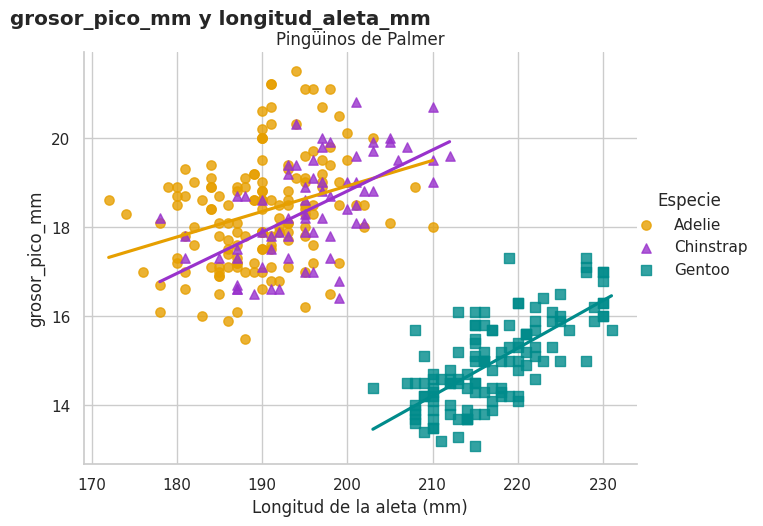

In [167]:



g = sns.lmplot(
    data=data, x='longitud_aleta_mm', y='grosor_pico_mm', hue='species',
    hue_order=['Adelie', 'Chinstrap', 'Gentoo'],
    palette={'Adelie': '#E69F00', 'Chinstrap': '#9932CC', 'Gentoo': '#008B8B'},
    markers=['o', '^', 's'], scatter_kws={'s': 45}, ci=None, height=5, aspect=1.3
)

g.fig.suptitle('grosor_pico_mm y longitud_aleta_mm', x=0.02, y=1.05, ha='left', fontweight='bold')
g.ax.set(title='Pingüinos de Palmer', xlabel='Longitud de la aleta (mm)', ylabel='grosor_pico_mm')
g._legend.set_title('Especie')
sns.move_legend(g, "center left", bbox_to_anchor=(0.8, 0.6))


plt.show()

El gráfico ilustra la relación entre el grosor del pico y la longitud de la aleta, reconfirmando la presencia de la Paradoja de Simpson al evaluar las tendencias globales frente a las intraespecíficas. A nivel agrupado, Adelie y Chinstrap muestran un solapamiento directo en el extremo superior izquierdo, compartiendo rangos de aletas más cortas ($170\text{ mm} - 210\text{ mm}$) y picos sustancialmente más gruesos ($16\text{ mm} - 21\text{ mm}$), con líneas de regresión de pendiente positiva que indican un incremento proporcional del grosor del pico al aumentar la extensión de la aleta. Por su parte, la especie Gentoo se aísla por completo en el sector inferior derecho, destacándose por tener las aletas más largas ($203\text{ mm} - 231\text{ mm}$) pero los picos más delgados ($13\text{ mm} - 17.5\text{ mm}$), manteniendo también una tendencia individual positiva. Esta clara separación en dos grandes bloques visuales demuestra cómo la mezcla de poblaciones distorsiona la correlación global a una dirección negativa, mientras que el análisis segmentado valida un crecimiento alométrico concordante dentro de cada grupo.


## Conclusión

La especie Gentoo destaca por presentar la menor profundidad de pico, combinada con la mayor longitud de aleta y masa corporal de todo el estudio.

Adelie se distingue principalmente por registrar la menor longitud de pico entre los tres grupos.

Las especies Adelie y Chinstrap comparten rangos muy similares en peso y tamaño de aleta, lo que genera una superposición visual en los gráficos y dificulta su separación directa.

Dentro de cada grupo, existe una correlación positiva donde todas las características físicas aumentan a la par del tamaño corporal.

Evaluar el dataset de forma global crea relaciones engañosas (como sugerir que a mayor masa, el pico es más delgado). Analizar los datos segmentando por especie es indispensable para reflejar la realidad biológica (Paradoja de Simpson).